![卷积神经网络图像分类器](images/卷积神经网络图像分类器.png)

# 知识要点
- 数据加载与归一
- 定义神经网络
- 定义损失函数
- 训练、测试神经网络
- 神经网络存储与读取

<br>

## 数据加载与归一
- 数据加载
    - 把训练数据导入到神经网络中并对神经网络进行训练
    -  图像分类器训练数据一般较大，无法一次性加载所有数据
        - 例如
            - CIFAR10数据集含有10个类6万张图片
            - ImageNet数据集包含1000个类超过100万张图片
        - 需要用mini-batch形式进行加载并训练
            - 每个mini-batch只加载所有训练数据集中的一部分数据
            - 任意两个mini-batch之间的数据不重叠
            - 当所有训练数据集中的数据都被加载并训练完一次被称为一个epoch
- 数据归一
    - 图像数据像素值一般在[0-255]
    - 在训练神经网络时，我们经常把输入数据值变成[0-1]或[-1 - 1]之间。可以加速收敛、提高模型稳定性、避免梯度消失和梯度爆炸问题，并提高模型的泛化能力
- PyTorch库
    - 数据加载
        - torchvision.dataset
            - 知名数据集可用torchvision.dataset.数据集名称加载
                - 例如：torchvision.datasets.CIFAR10 加载CIFAR10数据集
            - 私人数据集可用torchvision.dataset.ImageFolder 和 torch.utils.data.DataLoader加载
    - 数据归一
        - torchvision.transforms

## 常用公共数据集加载
### 数据集 CIFAR10
- CIFAR10是学习阶段常用的小型图像数据集
- CIFAR10有10类
    - 每类6000张图片
- 图像大小：32 * 32 * 3
    - 每张图有R、G、B三个通道
    - 每个通道有32*32个像素

![数据集CIFAR10](images/数据集CIFAR10.png)
           

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

In [2]:
# 定义数据转换
transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

# 加载训练数据集
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True, num_workers=2) # batch_size 影响

# 加载测试数据集
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


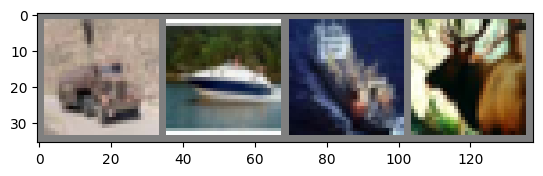

In [3]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 定义显示图像的函数
def imshow(img):
    # 输入数据：torch.tensor [c, h, w]
    img = img / 2 + 0.5  # 反归一化
    np_img = img.numpy()
    np_img = np.transpose(np_img, (1,2,0)) # [h,w,c]
    plt.imshow(np_img)
    plt.show()

# 获取一个批次的数据
dataiter = iter(train_loader) # 随机加载一个mini batch。随机是为了避免学习到顺序行的知识，提高模型的泛化能力
images, labels = next(dataiter)  # 使用 next() 函数

# 显示图像
imshow(torchvision.utils.make_grid(images))

## 加载私人数据集

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
# 定义数据转换
transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

# 加载训练数据集
private_set = torchvision.datasets.ImageFolder(root=image_path, transform=transforms)
pri_dataloader = torch.utils.data.DataLoader(private_set, batch_size=4, shuffle=False, num_workers=2)

- PyTorch会将image_path下面的数据在训练或测试时自动加载
- 在训练模型的时候，PyTorch会根据image_path下子文件夹的名称自动给所加载的数据添加标签
- 在加载私人数据集的时候，数据集所在文件夹应保持一下结构：
```plaintext
dataset_root/
    class_1/
        image1.jpg
        image2.jpg
        ...
    class_2/
        image1.jpg
        image2.jpg
        ...
    class_3/
        image1.jpg
        image2.jpg
        ...
    ... 

## 定义神经网络

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [7]:
class Net(nn.Module):
    def __init__(self): # 定义神经网络结构，输入数据 3*32*32
        super(Net, self).__init__()
        # 第一层（卷积层）
        self.conv1 = nn.Conv2d(3, 6, 3) # 输入频道3， 输出频道6， 卷积3*3
        # 第二层（卷积层）
        self.conv2 = nn.Conv2d(6, 16, 3) # 输入频道6， 输出频道16， 卷积3*3
        # 第三层（全连接层）
        self.fc1 = nn.Linear(16*28*28, 512) # 输入维度16*28*28=12544，输出维度512.这里的28，是因为经过每一层都会减2，32-2-2=28
        # 第四层（全连接层）
        self.fc2 = nn.Linear(512, 64) # 输入维度512， 输出维度64
        # 第五层（全连接层）
        self.fc3 = nn.Linear(64, 10) # 输入维度64， 输出维度10
        
    def forward(self, x): # 定义数据流向
        x = self.conv1(x)
        x = F.relu(x) # 激活函数
        # 非线性变换是指输入和输出之间不满足线性关系的数学操作。在神经网络中，激活函数（如ReLU、Sigmoid等）就是典型的非线性变换工具。它的核心作用是让神经网络能够学习和表示复杂的、非线性的数据模式
        # 示例：
        # 线性​：y=2x+1（输入翻倍，输出严格翻倍）
        # 非线性​：y=sin(x)（输入输出无固定比例关系）
        
        x = self.conv2(x)
        x = F.relu(x)
        
        x = x.view(-1, 16*28*28) # 将卷积层的输出张量重新调整形状，以便输入到全连接层，这个操作通过被成为“展平”。-1表示让torch自动计算该维度的大小，以确保元素总数不变，16 * 28 * 28：这是卷积层输出的特征图的总元素数量。16 是通道数，28 是高度，28 是宽度
        x = self.fc1(x)
        x = F.relu(x)
        
        x = self.fc2(x)
        x = F.relu(x)
        
        x = self.fc3(x) # 在神经网络的最后一层通常不需要使用激活函数，最后一层的输出通常会直接传递给损失函数进行计算
        
        return x

这段代码构建的卷积神经网络（CNN）通过"转来转去"的多层结构，实际上完成了**从原始像素到高级语义特征的智能转换**，具体作用如下：

---

### 1. **特征提取的逐层抽象化**
   - **第一层卷积（conv1）**  
     用3×3卷积核扫描输入图像，提取基础特征（如边缘、纹理）。  
     `输入3通道(RGB)→输出6通道`：相当于用6种不同滤镜观察图像。
   - **第二层卷积（conv2）**  
     在上一层的特征图上进一步组合，捕获更复杂模式（如形状、局部结构）。  
     `输入6通道→输出16通道`：形成16种高阶特征检测器。

   *类比*：就像人眼先看线条→再组合成轮廓→最后识别物体。

---

### 2. **维度转换与语义压缩**
   - **`x.view(-1, 16*28*28)`操作**  
     将二维特征图"压平"成一维向量（16×28×28=12544维），为全连接层做准备。  
     *相当于把散落的拼图块整理成一条信息链*。
   - **全连接层（fc1→fc2→fc3）**  
     逐步压缩信息：  
     `12544维→512维→64维→10维`，最终输出对应10个类别的概率分布。  
     *如同从1000字摘要→100字概要→10个关键词*。

---

### 3. **非线性建模能力**
   - 每个`ReLU`激活函数引入非线性，使网络能拟合复杂函数。  
     *类似给直线组合添加"弯折"能力，从而描绘曲线边界*。
   - 没有这些"转来转去"，网络就退化为简单的线性回归，无法处理图像复杂模式。

---

### 4. **实际应用场景**
   - **图像分类**：10维输出可对应MNIST数字识别（0-9）或CIFAR-10物体分类。
   - **特征工程**：中间层输出（如fc2的64维向量）可作为图像特征用于检索/聚类。
   - **迁移学习**：冻结卷积层（conv1/conv2）作为通用特征提取器，仅微调全连接层。

---

### 为什么需要这么多层？
- **浅层网络**：只能学习局部简单模式（如边缘）。
- **深层网络**：通过层层组合，最终识别全局语义（如"这是狗而不是猫"）。  
  *如同写作：字母→单词→句子→段落→文章*。

若删除任意一层，模型性能会显著下降。这种"转来转去"的结构，正是深度学习强大表征能力的核心所在。

In [8]:
net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=12544, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## 定义权值更新规则与损失函数

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # 学习率

## 训练神经网络

In [11]:
for epoch in range(2): # epoch次数
    for i, data in enumerate(train_loader):
        images, labels = data
        outputs = net(images)
        loss = criterion(outputs, labels) # 计算损失
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i%1000 == 0):
            print('Epoch: %d, Step: %d, Loss: %.3f' %(epoch, i, loss.item()))

Epoch: 0, Step: 0, Loss: 2.274
Epoch: 0, Step: 1000, Loss: 1.970
Epoch: 0, Step: 2000, Loss: 2.060
Epoch: 0, Step: 3000, Loss: 2.065
Epoch: 0, Step: 4000, Loss: 1.591
Epoch: 0, Step: 5000, Loss: 1.311
Epoch: 0, Step: 6000, Loss: 1.506
Epoch: 0, Step: 7000, Loss: 1.735
Epoch: 0, Step: 8000, Loss: 1.682
Epoch: 0, Step: 9000, Loss: 3.188
Epoch: 0, Step: 10000, Loss: 1.746
Epoch: 0, Step: 11000, Loss: 0.891
Epoch: 0, Step: 12000, Loss: 2.910
Epoch: 1, Step: 0, Loss: 1.240
Epoch: 1, Step: 1000, Loss: 1.090
Epoch: 1, Step: 2000, Loss: 1.747
Epoch: 1, Step: 3000, Loss: 1.671
Epoch: 1, Step: 4000, Loss: 1.944
Epoch: 1, Step: 5000, Loss: 1.496
Epoch: 1, Step: 6000, Loss: 0.879
Epoch: 1, Step: 7000, Loss: 0.482
Epoch: 1, Step: 8000, Loss: 1.220
Epoch: 1, Step: 9000, Loss: 1.774
Epoch: 1, Step: 10000, Loss: 0.257
Epoch: 1, Step: 11000, Loss: 0.546
Epoch: 1, Step: 12000, Loss: 1.772


## 影响loss
- 梯度下降优化器中的学习率
    - optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)，其中的lr，越小学的越好，但是相应的训练的时长越长
- 加载数据的batch_size，越大越大可能导致内存不足，训练速度变慢，但梯度估计更稳定，越小可能导致梯度估计不稳定，训练速度变快，但可能需要更多的迭代次数才能收敛
    - torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True, num_workers=2)
- 训练轮数epoch
    - 过少：可能导致模型欠拟合，无法充分学习数据中的模式
    - 过多：可能导致模型过拟合，学习到噪声和无关的模式
- 神经网络的层数

## loss 优化版

In [12]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)

In [13]:
# 检测 GPU 是否可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 将模型移动到 GPU
net.to(device)

Using device: cuda


Net(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=12544, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # 学习率
    # 训练
    net.train() # 将模型设置为训练模式
    running_loss = 0.0 # 初始化运行损失
    for i, data in enumerate(train_loader): # 遍历训练数据加载器
        images, labels = data # 获取训练图像和标签
        
        # 将数据移动到 GPU
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = net(images) # 前向传播，获取模型输出
        # 假设输入 batch_size=2，可能的输出：
        # outputs = tensor([[ 1.23, -0.45, 2.67, 0.89, -1.22, 3.01, -0.33, 1.56, 0.12, -2.34],
        #          [-0.99, 2.78, 0.45, 1.23, 4.56, -1.11, 0.67, -2.33, 3.21, 0.01]])
        # 样本1预测​：第6类（得分3.01最高）
        # ​样本2预测​：第5类（得分4.56最高）

        loss = criterion(outputs, labels) # 计算损失
        # labels = torch.tensor([3, 7, 0, 2])  # 假设batch_size=4，类别索引范围0-9
        
        # 在PyTorch中，nn.CrossEntropyLoss() 结合 outputs（模型预测的logits）和 labels（真实类别索引）计算损失的过程，虽然两者维度不同，但通过内部机制高效完成误差计算
        # 内部计算分解
        # 步骤1：Softmax归一化
        # 步骤2：提取目标概率
        # 步骤3：计算负对数损失

        
        optimizer.zero_grad() # 清零梯度。在每次反向传播之前，清零模型参数的梯度。这是为了避免梯度累积，确保每次反向传播都是基于当前批次的数据
        loss.backward() # 反向传播，计算梯度
        optimizer.step() # 更新模型参数，使损失指减小
        # 损失函数（Loss Function）用于衡量模型预测值与真实值之间的差异。损失值越小，表示模型的预测越接近真实值。损失函数是优化算法的目标函数，优化算法的目标是最小化损失值。
        # 梯度是一个向量，表示函数在某一点处的变化率。对于损失函数，梯度表示损失函数在模型参数空间中的变化率。作用：梯度指向损失函数增加最快的方向，负梯度指向损失函数减少最快的方向。优化算法（如梯度下降）利用梯度来更新模型参数，使损失值减小
        # 梯度是损失函数的导数：梯度是损失函数在模型参数空间中的导数，表示损失函数在每个参数上的变化率。梯度下降：优化算法通过计算损失函数的梯度，沿着负梯度方向更新模型参数，使损失值逐渐减小。
        
        running_loss += loss.item() # 累加运行损失
        if i%250 == 0: # 每250 mini batch 测试一次
            print('Epoch: %d, Steop: %d, Loss: %.3f' %(epoch, i, loss.item()))
            
            
            correct = 0.0
            total = 0.0
            
            net.eval() # 将模型设置为评估模式
            with torch.no_grad(): # 禁用梯度计算，节省内存
                for test_data in test_loader: # 遍历测试数据加载器
                    test_images, test_labels = test_data # 获取测试图像和标签
                    
                    # 将数据移动到 GPU
                    test_images = test_images.to(device)
                    test_labels = test_labels.to(device)
                    
                    test_outputs = net(test_images) # 前向传播，获取模型输出
                    test_loss = criterion(test_outputs, test_labels) # 计算测试损失
                    
            train_loss_hist.append(running_loss/250) # 记录训练损失
            test_loss_hist.append(test_loss.item()) # 记录测试损失
            running_loss=0.0 # 重置运行损失

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0, Steop: 0, Loss: 0.831
Epoch: 0, Steop: 250, Loss: 0.860
Epoch: 0, Steop: 500, Loss: 0.629
Epoch: 0, Steop: 750, Loss: 0.622
Epoch: 0, Steop: 1000, Loss: 2.118
Epoch: 0, Steop: 1250, Loss: 0.510
Epoch: 0, Steop: 1500, Loss: 0.476
Epoch: 0, Steop: 1750, Loss: 0.719
Epoch: 0, Steop: 2000, Loss: 2.212
Epoch: 0, Steop: 2250, Loss: 0.570
Epoch: 0, Steop: 2500, Loss: 0.673
Epoch: 0, Steop: 2750, Loss: 0.747
Epoch: 0, Steop: 3000, Loss: 1.158
Epoch: 0, Steop: 3250, Loss: 0.739
Epoch: 0, Steop: 3500, Loss: 0.837
Epoch: 0, Steop: 3750, Loss: 1.509
Epoch: 0, Steop: 4000, Loss: 0.896
Epoch: 0, Steop: 4250, Loss: 0.105
Epoch: 0, Steop: 4500, Loss: 1.234
Epoch: 0, Steop: 4750, Loss: 0.571
Epoch: 0, Steop: 5000, Loss: 1.293
Epoch: 0, Steop: 5250, Loss: 1.320
Epoch: 0, Steop: 5500, Loss: 0.970
Epoch: 0, Steop: 5750, Loss: 0.638
Epoch: 0, Steop: 6000, Loss: 0.376
Epoch: 0, Steop: 6250, Loss: 1.507
Epoch: 0, Steop: 6500, Loss: 0.674
Epoch: 0, Steop: 6750, Loss: 0.286
Epoch: 0, Steop: 7000, Los

  5%|▌         | 1/20 [07:44<2:27:11, 464.81s/it]

Epoch: 1, Steop: 0, Loss: 0.556
Epoch: 1, Steop: 250, Loss: 0.698
Epoch: 1, Steop: 500, Loss: 1.982
Epoch: 1, Steop: 750, Loss: 0.959
Epoch: 1, Steop: 1000, Loss: 0.641
Epoch: 1, Steop: 1250, Loss: 1.227
Epoch: 1, Steop: 1500, Loss: 0.922
Epoch: 1, Steop: 1750, Loss: 0.526
Epoch: 1, Steop: 2000, Loss: 0.930
Epoch: 1, Steop: 2250, Loss: 1.712
Epoch: 1, Steop: 2500, Loss: 0.504
Epoch: 1, Steop: 2750, Loss: 0.706
Epoch: 1, Steop: 3000, Loss: 1.312
Epoch: 1, Steop: 3250, Loss: 0.972
Epoch: 1, Steop: 3500, Loss: 0.673
Epoch: 1, Steop: 3750, Loss: 1.518
Epoch: 1, Steop: 4000, Loss: 0.333
Epoch: 1, Steop: 4250, Loss: 2.064
Epoch: 1, Steop: 4500, Loss: 0.220
Epoch: 1, Steop: 4750, Loss: 1.706
Epoch: 1, Steop: 5000, Loss: 1.558
Epoch: 1, Steop: 5250, Loss: 1.279
Epoch: 1, Steop: 5500, Loss: 0.169
Epoch: 1, Steop: 5750, Loss: 0.699
Epoch: 1, Steop: 6000, Loss: 0.714
Epoch: 1, Steop: 6250, Loss: 0.660
Epoch: 1, Steop: 6500, Loss: 0.929
Epoch: 1, Steop: 6750, Loss: 1.643
Epoch: 1, Steop: 7000, Los

 10%|█         | 2/20 [15:27<2:19:05, 463.66s/it]

...

 90%|█████████ | 18/20 [2:18:54<15:25, 462.90s/it]

Epoch: 18, Steop: 0, Loss: 0.001
Epoch: 18, Steop: 250, Loss: 0.000
Epoch: 18, Steop: 500, Loss: 0.001
Epoch: 18, Steop: 750, Loss: 0.000
Epoch: 18, Steop: 1000, Loss: 0.002
Epoch: 18, Steop: 1250, Loss: 0.001
Epoch: 18, Steop: 1500, Loss: 0.004
Epoch: 18, Steop: 1750, Loss: 0.004
Epoch: 18, Steop: 2000, Loss: 0.007
Epoch: 18, Steop: 2250, Loss: 0.017
Epoch: 18, Steop: 2500, Loss: 0.000
Epoch: 18, Steop: 2750, Loss: 0.001
Epoch: 18, Steop: 3000, Loss: 0.001
Epoch: 18, Steop: 3250, Loss: 0.003
Epoch: 18, Steop: 3500, Loss: 0.006
Epoch: 18, Steop: 3750, Loss: 0.001
Epoch: 18, Steop: 4000, Loss: 0.004
Epoch: 18, Steop: 4250, Loss: 0.002
Epoch: 18, Steop: 4500, Loss: 0.002
Epoch: 18, Steop: 4750, Loss: 0.000
Epoch: 18, Steop: 5000, Loss: 0.000
Epoch: 18, Steop: 5250, Loss: 0.001
Epoch: 18, Steop: 5500, Loss: 0.002
Epoch: 18, Steop: 5750, Loss: 0.000
Epoch: 18, Steop: 6000, Loss: 0.000
Epoch: 18, Steop: 6250, Loss: 0.001
Epoch: 18, Steop: 6500, Loss: 0.000
Epoch: 18, Steop: 6750, Loss: 0.00

 95%|█████████▌| 19/20 [2:26:35<07:42, 462.39s/it]

Epoch: 19, Steop: 0, Loss: 0.001
Epoch: 19, Steop: 250, Loss: 0.001
Epoch: 19, Steop: 500, Loss: 0.001
Epoch: 19, Steop: 750, Loss: 0.001
Epoch: 19, Steop: 1000, Loss: 0.001
Epoch: 19, Steop: 1250, Loss: 0.000
Epoch: 19, Steop: 1500, Loss: 0.001
Epoch: 19, Steop: 1750, Loss: 0.001
Epoch: 19, Steop: 2000, Loss: 0.001
Epoch: 19, Steop: 2250, Loss: 0.005
Epoch: 19, Steop: 2500, Loss: 0.000
Epoch: 19, Steop: 2750, Loss: 0.002
Epoch: 19, Steop: 3000, Loss: 0.000
Epoch: 19, Steop: 3250, Loss: 0.001
Epoch: 19, Steop: 3500, Loss: 0.001
Epoch: 19, Steop: 3750, Loss: 0.000
Epoch: 19, Steop: 4000, Loss: 0.000
Epoch: 19, Steop: 4250, Loss: 0.000
Epoch: 19, Steop: 4500, Loss: 0.000
Epoch: 19, Steop: 4750, Loss: 0.000
Epoch: 19, Steop: 5000, Loss: 0.001
Epoch: 19, Steop: 5250, Loss: 0.000
Epoch: 19, Steop: 5500, Loss: 0.000
Epoch: 19, Steop: 5750, Loss: 0.004
Epoch: 19, Steop: 6000, Loss: 0.000
Epoch: 19, Steop: 6250, Loss: 0.001
Epoch: 19, Steop: 6500, Loss: 0.001
Epoch: 19, Steop: 6750, Loss: 0.00

100%|██████████| 20/20 [2:34:15<00:00, 462.78s/it]


In [15]:
plt.figure() # 创建一个新的图形窗口
# plt.plot(temp)
plt.plot(test_loss_hist) # 绘制测试损失曲线，test_loss_hist 是测试损失值的列表或数组
plt.legend(('train loss', 'test loss')) # 添加图例，标识两条曲线的含义
plt.title('Train/Test Loss') # 设置图形的标题
plt.xlabel('# mini batch *250') # 设置 x 轴标签
plt.ylabel('Loss') # 设置 y 轴标签

Text(0, 0.5, 'Loss')

## 测试模型

In [ ]:
correct = 0.0
total = 0.0

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        
        outputs = net(images) # 模型输出的张量，通常是一个形状为 (batch_size, num_classes) 的张量，其中 batch_size 是批量大小，num_classes 是类别数量
        
        _, predicted = torch.max(outputs.data, 1) # 获取预测结果。在分类任务中，模型的输出通常是一个概率分布，表示每个类别的预测概率。为了确定模型的最终预测类别，我们需要选择概率最高的类别。torch.max 函数用于在模型的输出中找到概率最高的类别，并返回其索引。torch.max 函数可以在张量的指定维度上找到最大值及其索引，这里是在第二维度。返回两个值，第一个值是最大值（通常不需要），第二个值是最大值的索引（即预测的类别）
        
        correct += (predicted==labels).sum() # 累加正确预测的数量
        total += labels.size(0) # 累加总样本数量。张量的 size 方法返回张量的形状（shape），即张量在每个维度上的大小。对于标签张量 labels，通常是一个一维张量（即形状为 (batch_size,)），因此 labels.size(0) 返回的是批量大小（batch size）
        
print('准确率:', float(correct)/total)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # 学习率
    # 训练
    net.train() # 将模型设置为训练模式
    running_loss = 0.0 # 初始化运行损失
    for i, data in enumerate(train_loader): # 遍历训练数据加载器
        images, labels = data # 获取训练图像和标签
        
        # 将数据移动到 GPU
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = net(images) # 前向传播，获取模型输出
        # 假设输入 batch_size=2，可能的输出：
        # outputs = tensor([[ 1.23, -0.45, 2.67, 0.89, -1.22, 3.01, -0.33, 1.56, 0.12, -2.34],
        #          [-0.99, 2.78, 0.45, 1.23, 4.56, -1.11, 0.67, -2.33, 3.21, 0.01]])
        # 样本1预测​：第6类（得分3.01最高）
        # ​样本2预测​：第5类（得分4.56最高）

        loss = criterion(outputs, labels) # 计算损失
        # labels = torch.tensor([3, 7, 0, 2])  # 假设batch_size=4，类别索引范围0-9
        
        # 在PyTorch中，nn.CrossEntropyLoss() 结合 outputs（模型预测的logits）和 labels（真实类别索引）计算损失的过程，虽然两者维度不同，但通过内部机制高效完成误差计算
        # 内部计算分解
        # 步骤1：Softmax归一化
        # 步骤2：提取目标概率
        # 步骤3：计算负对数损失

        
        optimizer.zero_grad() # 清零梯度。在每次反向传播之前，清零模型参数的梯度。这是为了避免梯度累积，确保每次反向传播都是基于当前批次的数据
        loss.backward() # 反向传播，计算梯度
        optimizer.step() # 更新模型参数，使损失指减小
        # 损失函数（Loss Function）用于衡量模型预测值与真实值之间的差异。损失值越小，表示模型的预测越接近真实值。损失函数是优化算法的目标函数，优化算法的目标是最小化损失值。
        # 梯度是一个向量，表示函数在某一点处的变化率。对于损失函数，梯度表示损失函数在模型参数空间中的变化率。作用：梯度指向损失函数增加最快的方向，负梯度指向损失函数减少最快的方向。优化算法（如梯度下降）利用梯度来更新模型参数，使损失值减小
        # 梯度是损失函数的导数：梯度是损失函数在模型参数空间中的导数，表示损失函数在每个参数上的变化率。梯度下降：优化算法通过计算损失函数的梯度，沿着负梯度方向更新模型参数，使损失值逐渐减小。
        
        running_loss += loss.item() # 累加运行损失
        if i%250 == 0: # 每250 mini batch 测试一次
            print('Epoch: %d, Steop: %d, Loss: %.3f' %(epoch, i, loss.item()))
            
            
            correct = 0.0
            total = 0.0
            
            net.eval() # 将模型设置为评估模式
            with torch.no_grad(): # 禁用梯度计算，节省内存
                for test_data in test_loader: # 遍历测试数据加载器
                    test_images, test_labels = test_data # 获取测试图像和标签
                    
                    # 将数据移动到 GPU
                    test_images = test_images.to(device)
                    test_labels = test_labels.to(device)
                    
                    test_outputs = net(test_images) # 前向传播，获取模型输出
                    test_loss = criterion(test_outputs, test_labels) # 计算测试损失
                    
            train_loss_hist.append(running_loss/250) # 记录训练损失
            test_loss_hist.append(test_loss.item()) # 记录测试损失
            running_loss=0.0 # 重置运行损失

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0, Steop: 0, Loss: 0.831
Epoch: 0, Steop: 250, Loss: 0.860
Epoch: 0, Steop: 500, Loss: 0.629
Epoch: 0, Steop: 750, Loss: 0.622
Epoch: 0, Steop: 1000, Loss: 2.118
Epoch: 0, Steop: 1250, Loss: 0.510
Epoch: 0, Steop: 1500, Loss: 0.476
Epoch: 0, Steop: 1750, Loss: 0.719
Epoch: 0, Steop: 2000, Loss: 2.212
Epoch: 0, Steop: 2250, Loss: 0.570
Epoch: 0, Steop: 2500, Loss: 0.673
Epoch: 0, Steop: 2750, Loss: 0.747
Epoch: 0, Steop: 3000, Loss: 1.158
Epoch: 0, Steop: 3250, Loss: 0.739
Epoch: 0, Steop: 3500, Loss: 0.837
Epoch: 0, Steop: 3750, Loss: 1.509
Epoch: 0, Steop: 4000, Loss: 0.896
Epoch: 0, Steop: 4250, Loss: 0.105
Epoch: 0, Steop: 4500, Loss: 1.234
Epoch: 0, Steop: 4750, Loss: 0.571
Epoch: 0, Steop: 5000, Loss: 1.293
Epoch: 0, Steop: 5250, Loss: 1.320
Epoch: 0, Steop: 5500, Loss: 0.970
Epoch: 0, Steop: 5750, Loss: 0.638
Epoch: 0, Steop: 6000, Loss: 0.376
Epoch: 0, Steop: 6250, Loss: 1.507
Epoch: 0, Steop: 6500, Loss: 0.674
Epoch: 0, Steop: 6750, Loss: 0.286
Epoch: 0, Steop: 7000, Los

  5%|▌         | 1/20 [07:44<2:27:11, 464.81s/it]

Epoch: 1, Steop: 0, Loss: 0.556
Epoch: 1, Steop: 250, Loss: 0.698
Epoch: 1, Steop: 500, Loss: 1.982
Epoch: 1, Steop: 750, Loss: 0.959
Epoch: 1, Steop: 1000, Loss: 0.641
Epoch: 1, Steop: 1250, Loss: 1.227
Epoch: 1, Steop: 1500, Loss: 0.922
Epoch: 1, Steop: 1750, Loss: 0.526
Epoch: 1, Steop: 2000, Loss: 0.930
Epoch: 1, Steop: 2250, Loss: 1.712
Epoch: 1, Steop: 2500, Loss: 0.504
Epoch: 1, Steop: 2750, Loss: 0.706
Epoch: 1, Steop: 3000, Loss: 1.312
Epoch: 1, Steop: 3250, Loss: 0.972
Epoch: 1, Steop: 3500, Loss: 0.673
Epoch: 1, Steop: 3750, Loss: 1.518
Epoch: 1, Steop: 4000, Loss: 0.333
Epoch: 1, Steop: 4250, Loss: 2.064
Epoch: 1, Steop: 4500, Loss: 0.220
Epoch: 1, Steop: 4750, Loss: 1.706
Epoch: 1, Steop: 5000, Loss: 1.558
Epoch: 1, Steop: 5250, Loss: 1.279
Epoch: 1, Steop: 5500, Loss: 0.169
Epoch: 1, Steop: 5750, Loss: 0.699
Epoch: 1, Steop: 6000, Loss: 0.714
Epoch: 1, Steop: 6250, Loss: 0.660
Epoch: 1, Steop: 6500, Loss: 0.929
Epoch: 1, Steop: 6750, Loss: 1.643
Epoch: 1, Steop: 7000, Los

 10%|█         | 2/20 [15:27<2:19:05, 463.66s/it]

...

 90%|█████████ | 18/20 [2:18:54<15:25, 462.90s/it]

Epoch: 18, Steop: 0, Loss: 0.001
Epoch: 18, Steop: 250, Loss: 0.000
Epoch: 18, Steop: 500, Loss: 0.001
Epoch: 18, Steop: 750, Loss: 0.000
Epoch: 18, Steop: 1000, Loss: 0.002
Epoch: 18, Steop: 1250, Loss: 0.001
Epoch: 18, Steop: 1500, Loss: 0.004
Epoch: 18, Steop: 1750, Loss: 0.004
Epoch: 18, Steop: 2000, Loss: 0.007
Epoch: 18, Steop: 2250, Loss: 0.017
Epoch: 18, Steop: 2500, Loss: 0.000
Epoch: 18, Steop: 2750, Loss: 0.001
Epoch: 18, Steop: 3000, Loss: 0.001
Epoch: 18, Steop: 3250, Loss: 0.003
Epoch: 18, Steop: 3500, Loss: 0.006
Epoch: 18, Steop: 3750, Loss: 0.001
Epoch: 18, Steop: 4000, Loss: 0.004
Epoch: 18, Steop: 4250, Loss: 0.002
Epoch: 18, Steop: 4500, Loss: 0.002
Epoch: 18, Steop: 4750, Loss: 0.000
Epoch: 18, Steop: 5000, Loss: 0.000
Epoch: 18, Steop: 5250, Loss: 0.001
Epoch: 18, Steop: 5500, Loss: 0.002
Epoch: 18, Steop: 5750, Loss: 0.000
Epoch: 18, Steop: 6000, Loss: 0.000
Epoch: 18, Steop: 6250, Loss: 0.001
Epoch: 18, Steop: 6500, Loss: 0.000
Epoch: 18, Steop: 6750, Loss: 0.00

 95%|█████████▌| 19/20 [2:26:35<07:42, 462.39s/it]

Epoch: 19, Steop: 0, Loss: 0.001
Epoch: 19, Steop: 250, Loss: 0.001
Epoch: 19, Steop: 500, Loss: 0.001
Epoch: 19, Steop: 750, Loss: 0.001
Epoch: 19, Steop: 1000, Loss: 0.001
Epoch: 19, Steop: 1250, Loss: 0.000
Epoch: 19, Steop: 1500, Loss: 0.001
Epoch: 19, Steop: 1750, Loss: 0.001
Epoch: 19, Steop: 2000, Loss: 0.001
Epoch: 19, Steop: 2250, Loss: 0.005
Epoch: 19, Steop: 2500, Loss: 0.000
Epoch: 19, Steop: 2750, Loss: 0.002
Epoch: 19, Steop: 3000, Loss: 0.000
Epoch: 19, Steop: 3250, Loss: 0.001
Epoch: 19, Steop: 3500, Loss: 0.001
Epoch: 19, Steop: 3750, Loss: 0.000
Epoch: 19, Steop: 4000, Loss: 0.000
Epoch: 19, Steop: 4250, Loss: 0.000
Epoch: 19, Steop: 4500, Loss: 0.000
Epoch: 19, Steop: 4750, Loss: 0.000
Epoch: 19, Steop: 5000, Loss: 0.001
Epoch: 19, Steop: 5250, Loss: 0.000
Epoch: 19, Steop: 5500, Loss: 0.000
Epoch: 19, Steop: 5750, Loss: 0.004
Epoch: 19, Steop: 6000, Loss: 0.000
Epoch: 19, Steop: 6250, Loss: 0.001
Epoch: 19, Steop: 6500, Loss: 0.001
Epoch: 19, Steop: 6750, Loss: 0.00

100%|██████████| 20/20 [2:34:15<00:00, 462.78s/it]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # 学习率
    # 训练
    net.train() # 将模型设置为训练模式
    running_loss = 0.0 # 初始化运行损失
    for i, data in enumerate(train_loader): # 遍历训练数据加载器
        images, labels = data # 获取训练图像和标签
        
        # 将数据移动到 GPU
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = net(images) # 前向传播，获取模型输出
        # 假设输入 batch_size=2，可能的输出：
        # outputs = tensor([[ 1.23, -0.45, 2.67, 0.89, -1.22, 3.01, -0.33, 1.56, 0.12, -2.34],
        #          [-0.99, 2.78, 0.45, 1.23, 4.56, -1.11, 0.67, -2.33, 3.21, 0.01]])
        # 样本1预测​：第6类（得分3.01最高）
        # ​样本2预测​：第5类（得分4.56最高）

        loss = criterion(outputs, labels) # 计算损失
        # labels = torch.tensor([3, 7, 0, 2])  # 假设batch_size=4，类别索引范围0-9
        
        # 在PyTorch中，nn.CrossEntropyLoss() 结合 outputs（模型预测的logits）和 labels（真实类别索引）计算损失的过程，虽然两者维度不同，但通过内部机制高效完成误差计算
        # 内部计算分解
        # 步骤1：Softmax归一化
        # 步骤2：提取目标概率
        # 步骤3：计算负对数损失

        
        optimizer.zero_grad() # 清零梯度。在每次反向传播之前，清零模型参数的梯度。这是为了避免梯度累积，确保每次反向传播都是基于当前批次的数据
        loss.backward() # 反向传播，计算梯度
        optimizer.step() # 更新模型参数，使损失指减小
        # 损失函数（Loss Function）用于衡量模型预测值与真实值之间的差异。损失值越小，表示模型的预测越接近真实值。损失函数是优化算法的目标函数，优化算法的目标是最小化损失值。
        # 梯度是一个向量，表示函数在某一点处的变化率。对于损失函数，梯度表示损失函数在模型参数空间中的变化率。作用：梯度指向损失函数增加最快的方向，负梯度指向损失函数减少最快的方向。优化算法（如梯度下降）利用梯度来更新模型参数，使损失值减小
        # 梯度是损失函数的导数：梯度是损失函数在模型参数空间中的导数，表示损失函数在每个参数上的变化率。梯度下降：优化算法通过计算损失函数的梯度，沿着负梯度方向更新模型参数，使损失值逐渐减小。
        
        running_loss += loss.item() # 累加运行损失
        if i%250 == 0: # 每250 mini batch 测试一次
            print('Epoch: %d, Steop: %d, Loss: %.3f' %(epoch, i, loss.item()))
            
            
            correct = 0.0
            total = 0.0
            
            net.eval() # 将模型设置为评估模式
            with torch.no_grad(): # 禁用梯度计算，节省内存
                for test_data in test_loader: # 遍历测试数据加载器
                    test_images, test_labels = test_data # 获取测试图像和标签
                    
                    # 将数据移动到 GPU
                    test_images = test_images.to(device)
                    test_labels = test_labels.to(device)
                    
                    test_outputs = net(test_images) # 前向传播，获取模型输出
                    test_loss = criterion(test_outputs, test_labels) # 计算测试损失
                    
            train_loss_hist.append(running_loss/250) # 记录训练损失
            test_loss_hist.append(test_loss.item()) # 记录测试损失
            running_loss=0.0 # 重置运行损失

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0, Steop: 0, Loss: 0.831
Epoch: 0, Steop: 250, Loss: 0.860
Epoch: 0, Steop: 500, Loss: 0.629
Epoch: 0, Steop: 750, Loss: 0.622
Epoch: 0, Steop: 1000, Loss: 2.118
Epoch: 0, Steop: 1250, Loss: 0.510
Epoch: 0, Steop: 1500, Loss: 0.476
Epoch: 0, Steop: 1750, Loss: 0.719
Epoch: 0, Steop: 2000, Loss: 2.212
Epoch: 0, Steop: 2250, Loss: 0.570
Epoch: 0, Steop: 2500, Loss: 0.673
Epoch: 0, Steop: 2750, Loss: 0.747
Epoch: 0, Steop: 3000, Loss: 1.158
Epoch: 0, Steop: 3250, Loss: 0.739
Epoch: 0, Steop: 3500, Loss: 0.837
Epoch: 0, Steop: 3750, Loss: 1.509
Epoch: 0, Steop: 4000, Loss: 0.896
Epoch: 0, Steop: 4250, Loss: 0.105
Epoch: 0, Steop: 4500, Loss: 1.234
Epoch: 0, Steop: 4750, Loss: 0.571
Epoch: 0, Steop: 5000, Loss: 1.293
Epoch: 0, Steop: 5250, Loss: 1.320
Epoch: 0, Steop: 5500, Loss: 0.970
Epoch: 0, Steop: 5750, Loss: 0.638
Epoch: 0, Steop: 6000, Loss: 0.376
Epoch: 0, Steop: 6250, Loss: 1.507
Epoch: 0, Steop: 6500, Loss: 0.674
Epoch: 0, Steop: 6750, Loss: 0.286
Epoch: 0, Steop: 7000, Los

  5%|▌         | 1/20 [07:44<2:27:11, 464.81s/it]

Epoch: 1, Steop: 0, Loss: 0.556
Epoch: 1, Steop: 250, Loss: 0.698
Epoch: 1, Steop: 500, Loss: 1.982
Epoch: 1, Steop: 750, Loss: 0.959
Epoch: 1, Steop: 1000, Loss: 0.641
Epoch: 1, Steop: 1250, Loss: 1.227
Epoch: 1, Steop: 1500, Loss: 0.922
Epoch: 1, Steop: 1750, Loss: 0.526
Epoch: 1, Steop: 2000, Loss: 0.930
Epoch: 1, Steop: 2250, Loss: 1.712
Epoch: 1, Steop: 2500, Loss: 0.504
Epoch: 1, Steop: 2750, Loss: 0.706
Epoch: 1, Steop: 3000, Loss: 1.312
Epoch: 1, Steop: 3250, Loss: 0.972
Epoch: 1, Steop: 3500, Loss: 0.673
Epoch: 1, Steop: 3750, Loss: 1.518
Epoch: 1, Steop: 4000, Loss: 0.333
Epoch: 1, Steop: 4250, Loss: 2.064
Epoch: 1, Steop: 4500, Loss: 0.220
Epoch: 1, Steop: 4750, Loss: 1.706
Epoch: 1, Steop: 5000, Loss: 1.558
Epoch: 1, Steop: 5250, Loss: 1.279
Epoch: 1, Steop: 5500, Loss: 0.169
Epoch: 1, Steop: 5750, Loss: 0.699
Epoch: 1, Steop: 6000, Loss: 0.714
Epoch: 1, Steop: 6250, Loss: 0.660
Epoch: 1, Steop: 6500, Loss: 0.929
Epoch: 1, Steop: 6750, Loss: 1.643
Epoch: 1, Steop: 7000, Los

 10%|█         | 2/20 [15:27<2:19:05, 463.66s/it]

...

 90%|█████████ | 18/20 [2:18:54<15:25, 462.90s/it]

Epoch: 18, Steop: 0, Loss: 0.001
Epoch: 18, Steop: 250, Loss: 0.000
Epoch: 18, Steop: 500, Loss: 0.001
Epoch: 18, Steop: 750, Loss: 0.000
Epoch: 18, Steop: 1000, Loss: 0.002
Epoch: 18, Steop: 1250, Loss: 0.001
Epoch: 18, Steop: 1500, Loss: 0.004
Epoch: 18, Steop: 1750, Loss: 0.004
Epoch: 18, Steop: 2000, Loss: 0.007
Epoch: 18, Steop: 2250, Loss: 0.017
Epoch: 18, Steop: 2500, Loss: 0.000
Epoch: 18, Steop: 2750, Loss: 0.001
Epoch: 18, Steop: 3000, Loss: 0.001
Epoch: 18, Steop: 3250, Loss: 0.003
Epoch: 18, Steop: 3500, Loss: 0.006
Epoch: 18, Steop: 3750, Loss: 0.001
Epoch: 18, Steop: 4000, Loss: 0.004
Epoch: 18, Steop: 4250, Loss: 0.002
Epoch: 18, Steop: 4500, Loss: 0.002
Epoch: 18, Steop: 4750, Loss: 0.000
Epoch: 18, Steop: 5000, Loss: 0.000
Epoch: 18, Steop: 5250, Loss: 0.001
Epoch: 18, Steop: 5500, Loss: 0.002
Epoch: 18, Steop: 5750, Loss: 0.000
Epoch: 18, Steop: 6000, Loss: 0.000
Epoch: 18, Steop: 6250, Loss: 0.001
Epoch: 18, Steop: 6500, Loss: 0.000
Epoch: 18, Steop: 6750, Loss: 0.00

 95%|█████████▌| 19/20 [2:26:35<07:42, 462.39s/it]

Epoch: 19, Steop: 0, Loss: 0.001
Epoch: 19, Steop: 250, Loss: 0.001
Epoch: 19, Steop: 500, Loss: 0.001
Epoch: 19, Steop: 750, Loss: 0.001
Epoch: 19, Steop: 1000, Loss: 0.001
Epoch: 19, Steop: 1250, Loss: 0.000
Epoch: 19, Steop: 1500, Loss: 0.001
Epoch: 19, Steop: 1750, Loss: 0.001
Epoch: 19, Steop: 2000, Loss: 0.001
Epoch: 19, Steop: 2250, Loss: 0.005
Epoch: 19, Steop: 2500, Loss: 0.000
Epoch: 19, Steop: 2750, Loss: 0.002
Epoch: 19, Steop: 3000, Loss: 0.000
Epoch: 19, Steop: 3250, Loss: 0.001
Epoch: 19, Steop: 3500, Loss: 0.001
Epoch: 19, Steop: 3750, Loss: 0.000
Epoch: 19, Steop: 4000, Loss: 0.000
Epoch: 19, Steop: 4250, Loss: 0.000
Epoch: 19, Steop: 4500, Loss: 0.000
Epoch: 19, Steop: 4750, Loss: 0.000
Epoch: 19, Steop: 5000, Loss: 0.001
Epoch: 19, Steop: 5250, Loss: 0.000
Epoch: 19, Steop: 5500, Loss: 0.000
Epoch: 19, Steop: 5750, Loss: 0.004
Epoch: 19, Steop: 6000, Loss: 0.000
Epoch: 19, Steop: 6250, Loss: 0.001
Epoch: 19, Steop: 6500, Loss: 0.001
Epoch: 19, Steop: 6750, Loss: 0.00

100%|██████████| 20/20 [2:34:15<00:00, 462.78s/it]


## 神经网络的保存与载入
- 在实际应用中，我们经常需要存储、读取模型
- PyTorch提供了多种模型的存储与读取方式
    - 例如：
        - 保存模型进行推理
        - 保存整个模型
        - 保存checkpoints
        - 在CPU上保存模型，在GPU上读取模型等
- 在这里，我给大家介绍一下最常用的一个保存、读取方法
    - 保存模型进行推理
    - 我们需要用到：
        - torch.save
        - torch.load

- Python的dictionary对象
    - 存储和读取时，Pytorch会自动将模型中的每一个可学习层映射到一个单独的参数张量上
    - State_dict上的每个张量读取到对应的可学习层上

## 保存模型

In [17]:
torch.save(net.state_dict(), './model.pt')

## 读取模型

In [18]:
net_2 = Net() # 创建一个新的神经网络实例，此时模型参数是随机初始化的，没有经过训练

correct = 0.0
total = 0.0
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        
        outputs = net_2(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        correct += (predicted==labels).sum()
        total += labels.size(0)
        
print('准确率:', float(correct)/total) # 由于 net_2 是未训练的模型（参数随机初始化），预期结果应该是：
# 准确率很低，大约在 10% 左右（对于10分类问题）这相当于随机猜测的水平

准确率: 0.0996


In [ ]:
net_2.load_state_dict(torch.load('./model.pt'))

In [20]:
correct = 0.0
total = 0.0
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        
        outputs = net_2(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        correct += (predicted==labels).sum()
        total += labels.size(0)
        
print('准确率:', float(correct)/total)

准确率: 0.6285
